## Here, we can see that loadprices is a numpy array

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



pricesFile = "./prices.txt"
numTestDays = 250

def loadprices(fn):
    """
    load prices from csv file (one instrument per column) and transpose into one instrument per row
    """
    global nt, ninst
    df = pd.read_csv(fn, sep=r"\s+", header=0, index_col=None)
    nt, ninst = df.shape
    return (df.values).T

k = loadprices(pricesFile)
print(k)
print(type(k))


[[100.    98.49  97.83 ...  86.31  87.14  87.12]
 [116.51 112.94 112.7  ...  62.52  62.3   62.08]
 [113.55 114.53 112.17 ...  86.26  87.59  86.62]
 ...
 [ 66.43  64.66  64.19 ...  33.17  33.52  34.27]
 [ 22.41  22.1   20.87 ...   8.67   9.     9.14]
 [ 45.08  44.28  45.3  ...  17.58  17.93  17.83]]
<class 'numpy.ndarray'>


## Lets try implementing ema

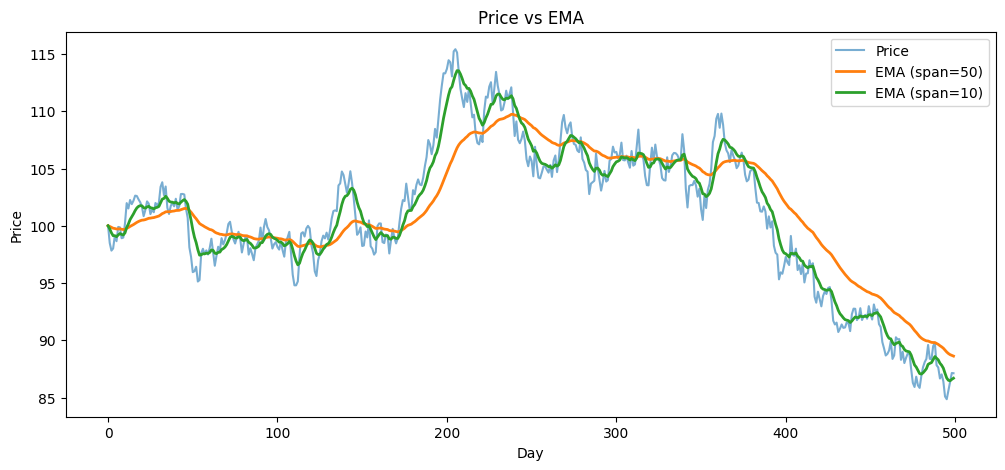

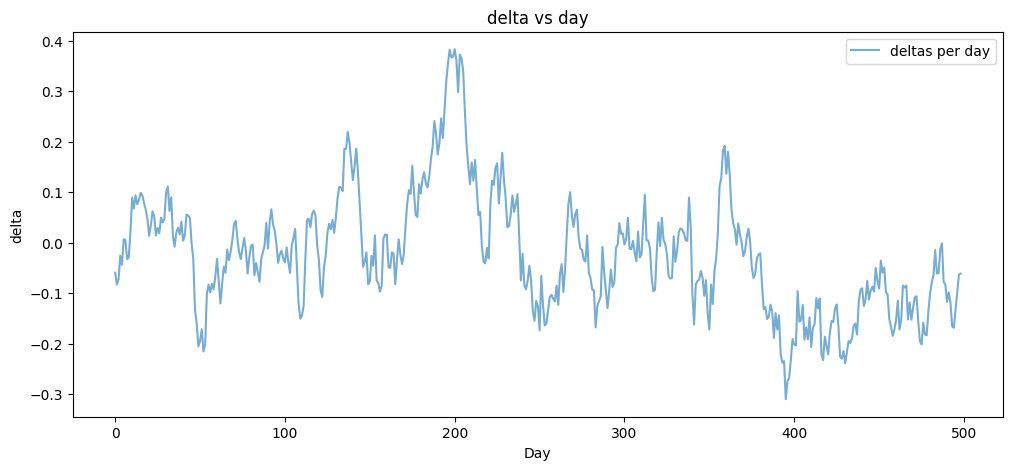

In [32]:
def loadprices(fn):
    """
    load prices from csv file (one instrument per column) and transpose into one instrument per row
    """
    global nt, ninst
    df = pd.read_csv(fn, sep=r"\s+", header=0, index_col=None)
    nt, ninst = df.shape
    return (df.values).T

def calc_ema(prices, N):
    alpha = 2 / (N + 1)
    ema_arr = [prices[0]]
    for i in range(1, prices.size):
        ema_arr.append(alpha * prices[i] + (1 - alpha) * ema_arr[i - 1])
    return ema_arr

item = 0
span = 50
prices = loadprices(pricesFile)     
ema  = calc_ema(prices[item], span)
plt.figure(figsize=(12, 5))
plt.plot(prices[item], label='Price', alpha=0.6)
plt.plot(ema, label=f'EMA (span={span})', linewidth=2)
plt.plot(calc_ema(prices[item], 10), label=f'EMA (span={10})', linewidth=2)
plt.legend()
plt.xlabel('Day')
plt.ylabel('Price')
plt.title('Price vs EMA')
plt.show()

deltas = []
for i in range(1, len(ema)):
    delta = ema[i] - ema[i-1]
    deltas.append(delta)


plt.figure(figsize=(12, 5))
plt.plot(deltas, label='deltas per day', alpha=0.6)
plt.legend()
plt.xlabel('Day')
plt.ylabel('delta')
plt.title('delta vs day')
plt.show()
